# Customer Churn Prediction using AI/Machine Learning

**Project:** IBM SkillsBuild — Data Analytics with AI Academic Internship
**Program:** Conducted by BharatCares, in association with AICTE
**Author:** Isha Sharma

---

## 1. Problem Statement

Customer churn (customers discontinuing a service) directly impacts the revenue of
subscription-based businesses such as telecom operators. Acquiring a new customer is
far more expensive than retaining an existing one, so being able to **predict which
customers are likely to churn** — and understanding **why** — allows a business to act
proactively (targeted offers, service improvements, retention campaigns).

This project analyzes a telecom company's customer data to:

1. Explore and understand the factors associated with customer churn (Data Analytics).
2. Build and compare multiple Machine Learning models that predict churn (AI).
3. Translate the model's findings into actionable business recommendations.

## 2. Dataset

- **Name:** Telco Customer Churn
- **Source:** [Kaggle — Telco Customer Churn (blastchar/telco-customer-churn)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
  (originally published by IBM as a sample dataset for customer retention analytics;
  the identical data is mirrored on IBM's own GitHub and used here as `data/Telco-Customer-Churn.csv`)
- **Size:** 7,043 customers × 21 columns
- **Target variable:** `Churn` (Yes / No)
- **Feature types:** customer demographics, account information (tenure, contract,
  billing), and subscribed services (phone, internet, streaming, security add-ons).


In [1]:
# 3. Import Libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42


## 4. Load the Dataset

In [2]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")
print("Shape:", df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 5. Data Cleaning & Preprocessing

In [4]:
# 'TotalCharges' is read as object because a handful of rows contain blank strings
# (new customers with 0 tenure). Convert to numeric and inspect the result.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing values after conversion:\n", df.isnull().sum()[df.isnull().sum() > 0])


Missing values after conversion:
 TotalCharges    11
dtype: int64


In [5]:
# These blanks correspond to customers with tenure == 0 (they have not been
# billed yet), so it is reasonable to fill TotalCharges with 0 for them.
df.loc[df["TotalCharges"].isnull(), ["tenure", "MonthlyCharges", "TotalCharges"]]


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [6]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# customerID is a unique identifier and carries no predictive signal
df.drop(columns=["customerID"], inplace=True)

# Standardise the "No internet service" / "No phone service" labels to "No"
# so that each service column is a clean binary Yes/No feature
service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                 "TechSupport", "StreamingTV", "StreamingMovies"]
for col in service_cols:
    df[col] = df[col].replace("No internet service", "No")
df["MultipleLines"] = df["MultipleLines"].replace("No phone service", "No")

print("Duplicate rows after dropping customerID:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)


Duplicate rows after dropping customerID: 22
Shape after removing duplicates: (7021, 20)


**Note:** Once `customerID` (a unique identifier) is removed, a small number of
rows (22) become exact duplicates on the remaining feature columns — i.e. different
customers who coincidentally share identical demographic/account/service profiles.
These are dropped to avoid giving the model (and the EDA) redundant, double-counted
records. The dataset now has no missing values and consistent categorical labels.

## 6. Exploratory Data Analysis (EDA)

Churn
No     5164
Yes    1857
Name: count, dtype: int64

Overall churn rate: 26.4%


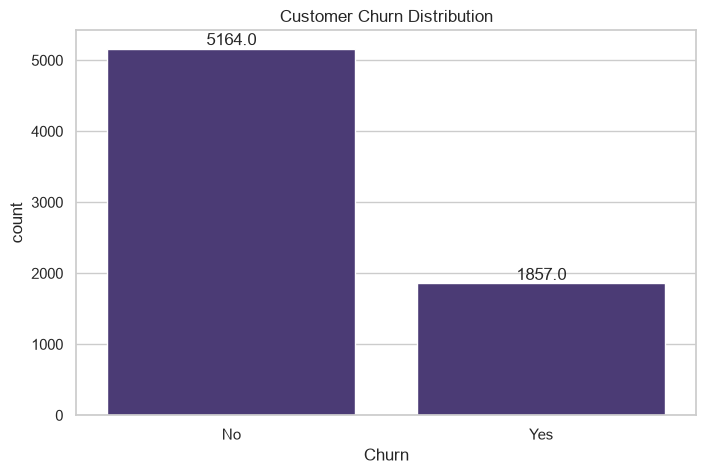

In [7]:
churn_counts = df["Churn"].value_counts()
churn_rate = churn_counts["Yes"] / len(df) * 100
print(churn_counts)
print(f"\nOverall churn rate: {churn_rate:.1f}%")

fig, ax = plt.subplots()
sns.countplot(data=df, x="Churn", ax=ax)
ax.set_title("Customer Churn Distribution")
for p in ax.patches:
    ax.annotate(f"{p.get_height()}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()


**Observation:** About 1 in 4 customers (26.5%) in this dataset has churned.
The classes are imbalanced, which we account for later using SMOTE oversampling.

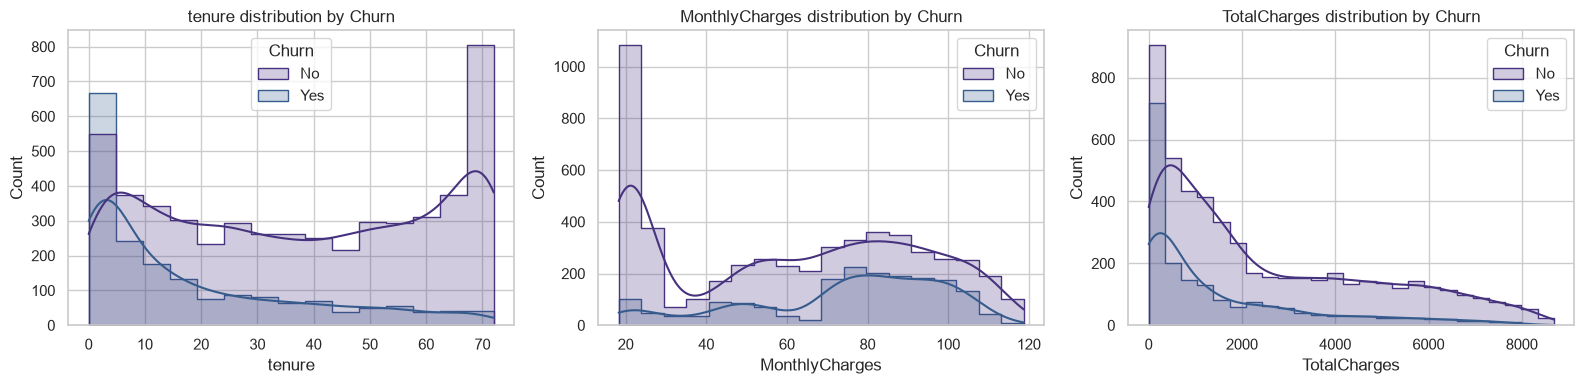

In [8]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=df, x=col, hue="Churn", kde=True, ax=ax, element="step")
    ax.set_title(f"{col} distribution by Churn")
plt.tight_layout()
plt.show()


**Observation:** Customers who churn tend to have **low tenure** (leave within
the first few months) and **higher monthly charges**. Long-tenure, low-monthly-charge
customers are the most loyal segment.

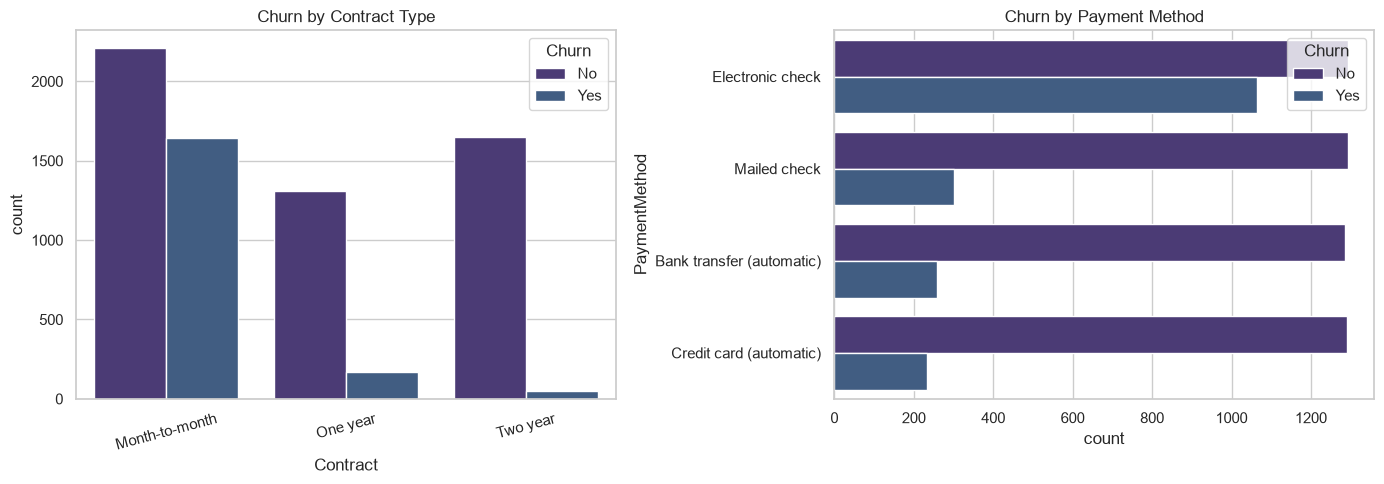

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="Contract", hue="Churn", ax=axes[0])
axes[0].set_title("Churn by Contract Type")
axes[0].tick_params(axis="x", rotation=15)

sns.countplot(data=df, y="PaymentMethod", hue="Churn", ax=axes[1])
axes[1].set_title("Churn by Payment Method")

plt.tight_layout()
plt.show()


**Observation:** Customers on **month-to-month contracts** and those paying via
**electronic check** churn at a much higher rate than customers on one/two-year
contracts or automatic payment methods. This points to a lack of commitment/lock-in
as a major churn driver.

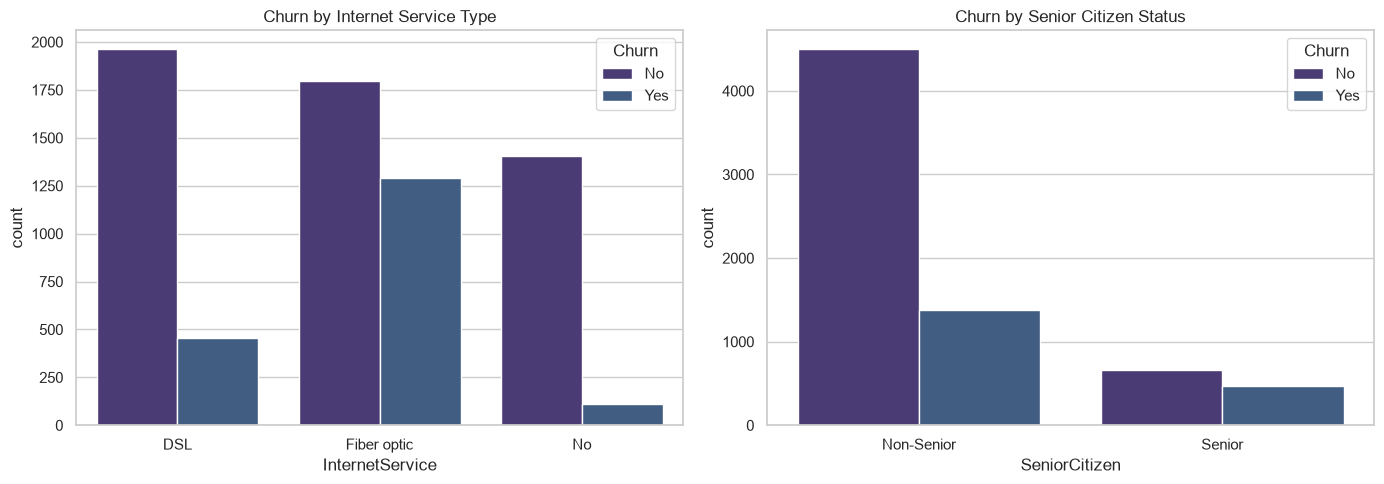

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="InternetService", hue="Churn", ax=axes[0])
axes[0].set_title("Churn by Internet Service Type")

sns.countplot(data=df, x="SeniorCitizen", hue="Churn", ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Non-Senior", "Senior"])
axes[1].set_title("Churn by Senior Citizen Status")

plt.tight_layout()
plt.show()


**Observation:** Customers with **Fiber optic** internet churn noticeably more
than DSL or no-internet customers (often linked to higher pricing / competition).
**Senior citizens** also churn at a higher relative rate than non-seniors.

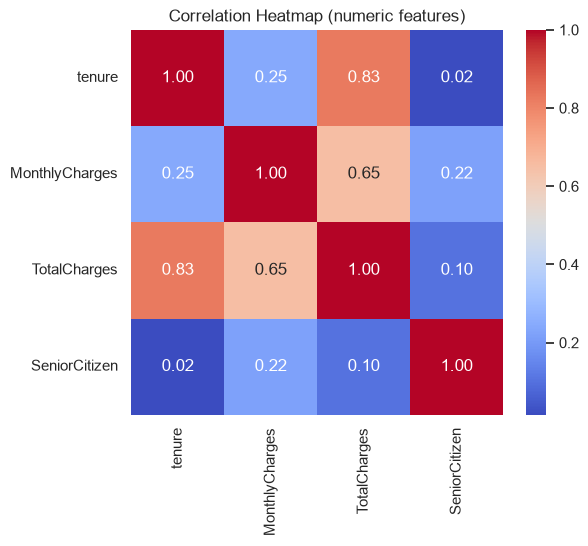

In [11]:
plt.figure(figsize=(6, 5))
corr = df[numeric_cols + ["SeniorCitizen"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (numeric features)")
plt.show()


## 7. Feature Engineering

In [12]:
model_df = df.copy()

# Binary Yes/No (and gender) columns -> 0/1
binary_cols = ["Partner", "Dependents", "PhoneService", "MultipleLines",
               "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
               "StreamingTV", "StreamingMovies", "PaperlessBilling", "Churn"]
le = LabelEncoder()
for col in binary_cols:
    model_df[col] = le.fit_transform(model_df[col])

model_df["gender"] = model_df["gender"].map({"Male": 1, "Female": 0})

# Multi-category columns -> one-hot encoding
multi_cols = ["InternetService", "Contract", "PaymentMethod"]
model_df = pd.get_dummies(model_df, columns=multi_cols, drop_first=True)

print("Final feature matrix shape:", model_df.shape)
model_df.head()


Final feature matrix shape: (7021, 24)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False


## 8. Train / Test Split, Scaling & Class Balancing

In [13]:
X = model_df.drop(columns=["Churn"])
y = model_df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train class balance before SMOTE:\n", y_train.value_counts())

smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("\nTrain class balance after SMOTE:\n", pd.Series(y_train_bal).value_counts())


Train class balance before SMOTE:
 Churn
0    4131
1    1485
Name: count, dtype: int64

Train class balance after SMOTE:
 Churn
1    4131
0    4131
Name: count, dtype: int64


## 9. Model Building (AI Classification Models)

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=10, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    fitted_models[name] = model

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).set_index("Model").sort_values("ROC-AUC", ascending=False)
results_df.round(3)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Gradient Boosting,0.781,0.574,0.675,0.621,0.842
Logistic Regression,0.742,0.509,0.763,0.611,0.840
Random Forest,0.778,0.566,0.691,0.622,0.840
Decision Tree,0.743,0.510,0.785,0.618,0.819


## 10. Model Evaluation

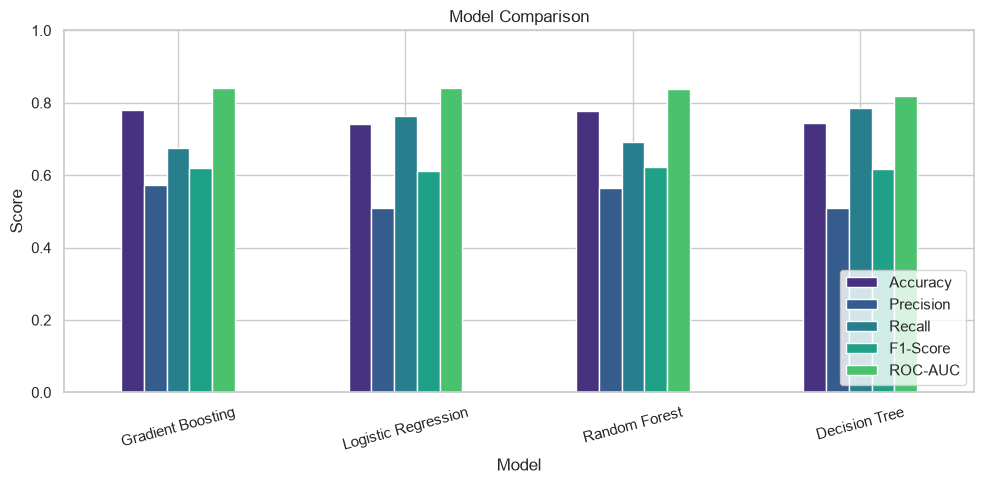

In [15]:
results_df[["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]].plot(
    kind="bar", figsize=(10, 5)
)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [16]:
best_model_name = results_df["ROC-AUC"].idxmax()
best_model = fitted_models[best_model_name]
print("Best model by ROC-AUC:", best_model_name)

y_pred_best = best_model.predict(X_test_scaled)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best, target_names=["No Churn", "Churn"]))


Best model by ROC-AUC: Gradient Boosting

Classification Report:

              precision    recall  f1-score   support

    No Churn       0.88      0.82      0.85      1033
       Churn       0.57      0.67      0.62       372

    accuracy                           0.78      1405
   macro avg       0.72      0.75      0.73      1405
weighted avg       0.80      0.78      0.79      1405



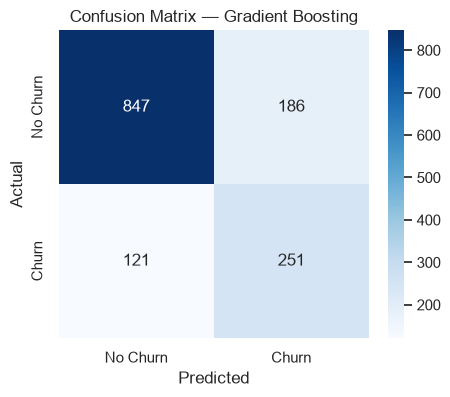

In [17]:
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title(f"Confusion Matrix — {best_model_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


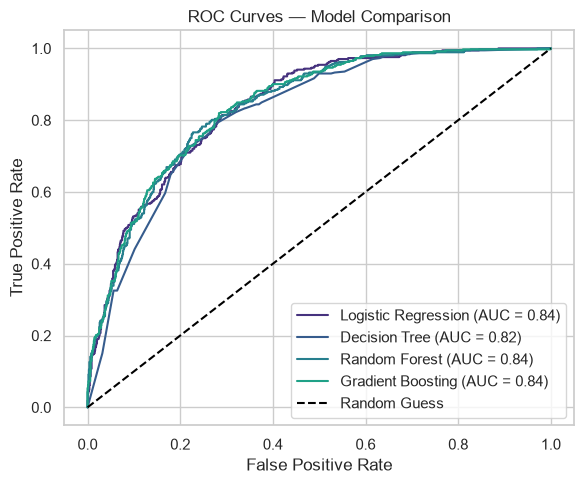

In [18]:
plt.figure(figsize=(6, 5))
for name, model in fitted_models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()


## 11. Feature Importance (Random Forest)

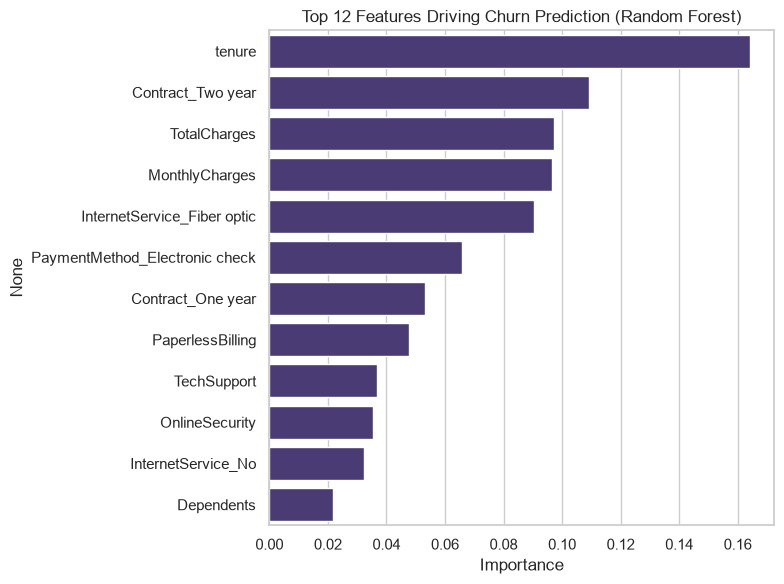

In [19]:
rf_model = fitted_models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(12)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top 12 Features Driving Churn Prediction (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


**Observation:** Tenure, total/monthly charges, contract type, and internet
service type are consistently the strongest predictors of churn — confirming the
patterns already seen in the EDA.

## 12. Key Insights

1. **Contract type is the single biggest churn driver.** Month-to-month customers
   churn far more than those on 1- or 2-year contracts, which lock customers in and
   correlate with loyalty.
2. **New customers are the most at risk.** Churn is heavily concentrated in the first
   ~12 months of tenure — a strong "welcome period" retention program would have
   outsized impact.
3. **Price sensitivity matters.** Higher `MonthlyCharges`, especially combined with
   Fiber optic internet, is associated with higher churn — customers may feel they
   are not getting proportional value.
4. **Payment friction correlates with churn.** Customers paying via electronic check
   (a manual, non-automatic method) churn more than those on automatic bank
   transfer/credit card payments.
5. **Add-on services reduce churn.** Customers without OnlineSecurity/TechSupport
   churn more — these services appear to increase perceived value and stickiness.

## 13. Business Recommendations

- Offer incentives (discounts, bundled services) to convert month-to-month
  customers onto longer-term contracts.
- Create a dedicated onboarding/retention journey for the first 3–12 months of a
  customer's lifecycle.
- Review Fiber optic pricing/competitiveness and bundle add-on services
  (security, tech support) into higher-tier plans at low marginal cost.
- Encourage automatic payment methods (credit card / bank transfer) through
  small incentives to reduce payment-related friction and churn.
- Use the trained model to score the active customer base monthly and proactively
  reach out to customers with a high predicted churn probability.

## 14. Conclusion

This project walked through a full data analytics + AI pipeline — data cleaning,
exploratory analysis, feature engineering, and training/evaluating four different
classification models — to predict telecom customer churn. The best-performing
model (selected by ROC-AUC) can be used by the business to proactively identify
at-risk customers and prioritize retention efforts, directly supporting revenue
protection and customer-experience initiatives.

---
*Submitted as part of the IBM SkillsBuild Data Analytics with AI Academic
Internship Program, conducted by BharatCares in association with AICTE.*
